# 11. 커뮤니케이션 (https://r4ds.hadley.nz/communication)

In [1]:
library(tidyverse)
library(scales)
library(ggrepel)
library(patchwork)

Warning message:
"package 'tidyverse' was built under R version 4.3.3"
Warning message:
"package 'ggplot2' was built under R version 4.3.3"
Warning message:
"package 'tidyr' was built under R version 4.3.3"
Warning message:
"package 'readr' was built under R version 4.3.3"
Warning message:
"package 'dplyr' was built under R version 4.3.3"
Warning message:
"package 'stringr' was built under R version 4.3.2"
Warning message:
"package 'forcats' was built under R version 4.3.3"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicte

## 11.2 라벨

In [2]:
head(mpg)

manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


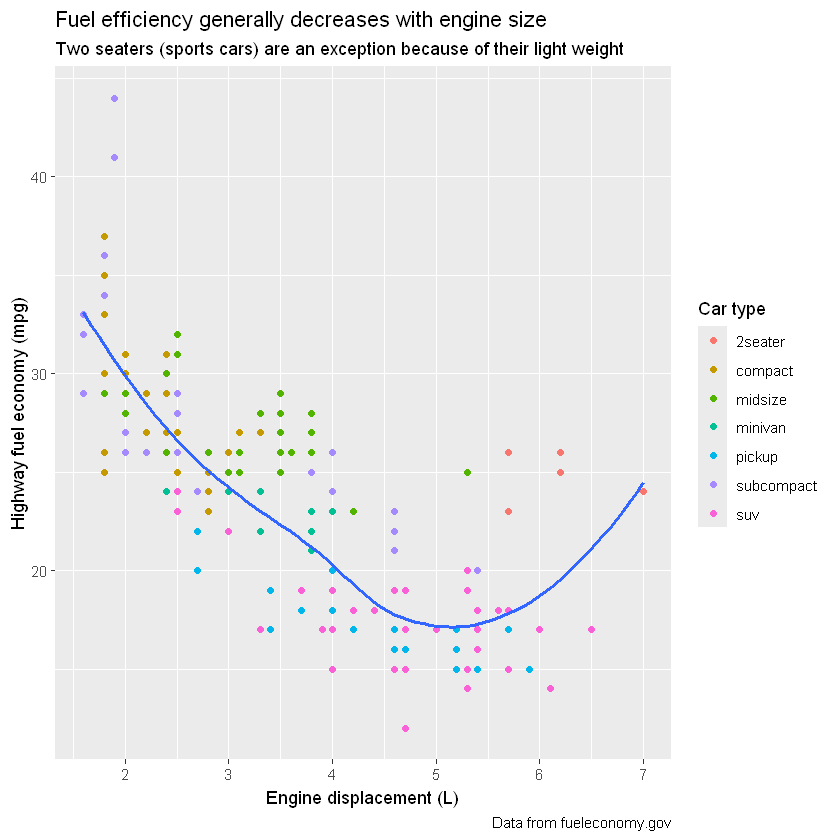

In [3]:
ggplot(mpg, aes(x = displ, y = hwy)) +
  geom_point(aes(color = class)) +
  geom_smooth(se = FALSE) +
  labs(
    x = "Engine displacement (L)",
    y = "Highway fuel economy (mpg)",
    color = "Car type",
    title = "Fuel efficiency generally decreases with engine size",
    subtitle = "Two seaters (sports cars) are an exception because of their light weight",
    caption = "Data from fueleconomy.gov"
  )

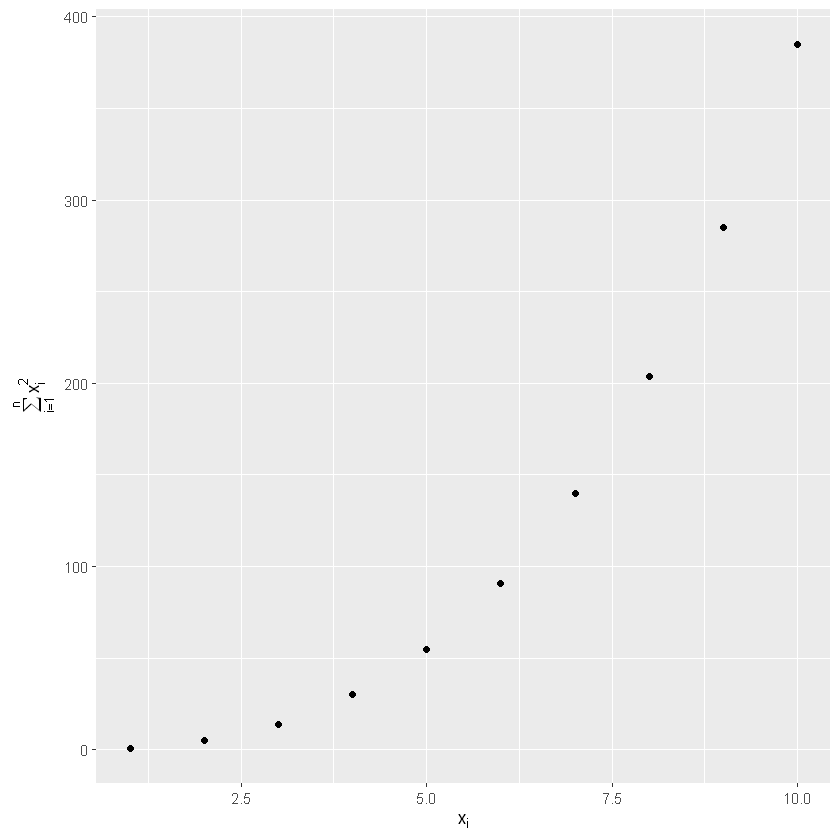

In [4]:
df <- tibble(
  x = 1:10,
  y = cumsum(x^2)
)

ggplot(df, aes(x, y)) +
  geom_point() +
  labs(
    x = quote(x[i]),
    y = quote(sum(x[i] ^ 2, i == 1, n))
  )

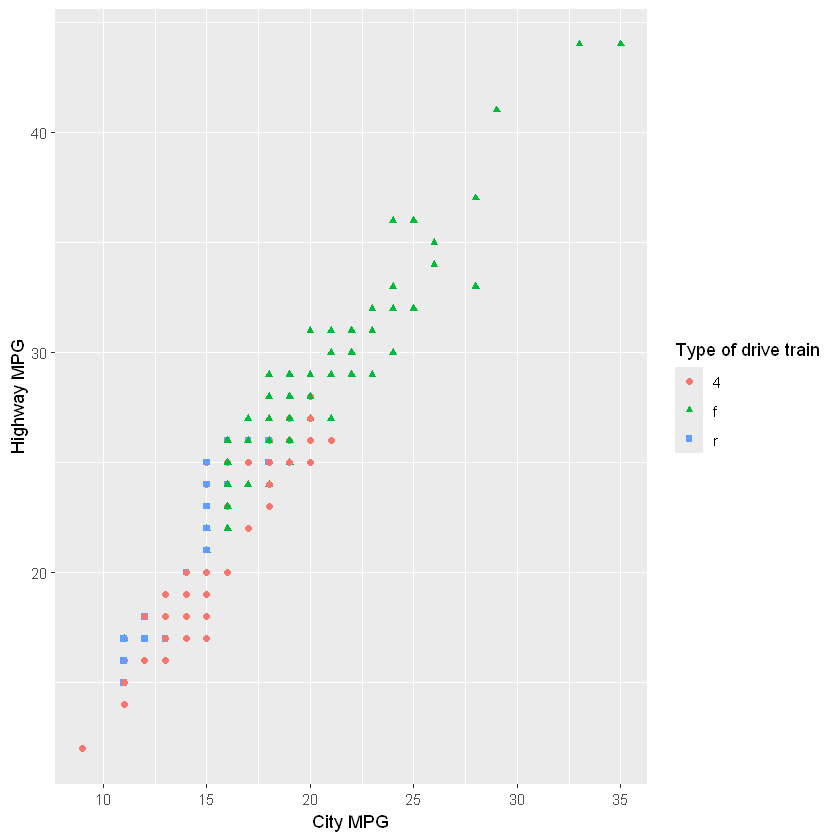

In [5]:
ggplot(mpg,aes(x=cty, y=hwy,color=drv,shape=drv))+
geom_point()+
labs(
x ="City MPG",
y= "Highway MPG",
color= "Type of drive train",
shape= "Type of drive train")

---

## 11.3 주석

In [6]:
label_info <- mpg |>
group_by(drv) |>
arrange(desc(displ)) |>
slice_head(n=1) |>
mutate(
drive_type=case_when(
drv =="f" ~ "front-wheel-drive",
drv == "r" ~ "rear-wheel drive",
drv == "4" ~ "4-wheel drive")) |>
select(displ,hwy,drv,drive_type)

label_info

displ,hwy,drv,drive_type
<dbl>,<int>,<chr>,<chr>
6.5,17,4,4-wheel drive
5.3,25,f,front-wheel-drive
7.0,24,r,rear-wheel drive


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


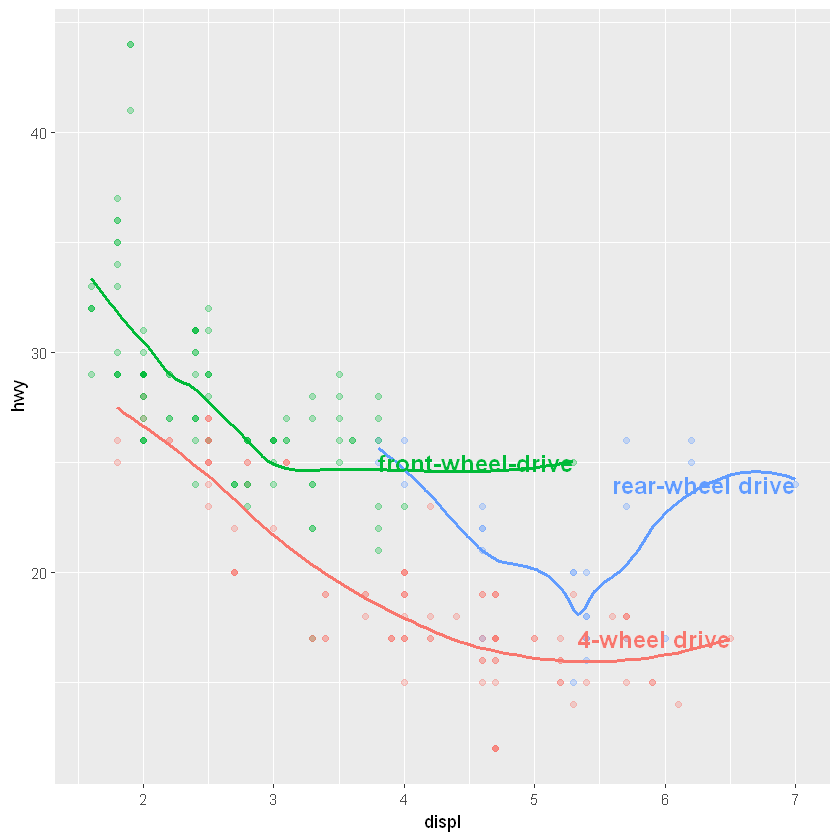

In [7]:
ggplot(mpg, aes(x=displ, y=hwy, color=drv))+
geom_point(alpha=0.3)+
geom_smooth(se=F)+
geom_text(
data=label_info,
aes(x=displ, y=hwy, label=drive_type),
fontface="bold", size=5, hjust="right",vjust="bottome")+
theme(legend.position="none")

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


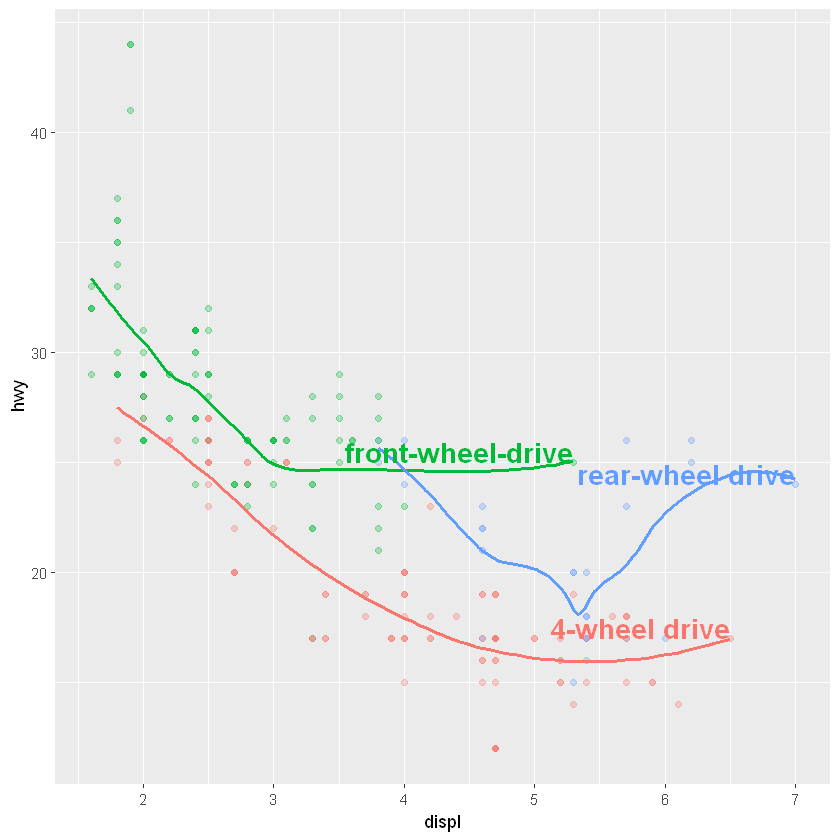

In [8]:
ggplot(mpg, aes(x=displ, y=hwy, color=drv))+
geom_point(alpha=0.3)+
geom_smooth(se=F)+
geom_text(
data=label_info,
aes(x=displ, y=hwy, label=drive_type),
fontface="bold", size=6, hjust="right",vjust="bottom")+
theme(legend.position="none")
# hjust(수평정렬), vjust(수직정렬)

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


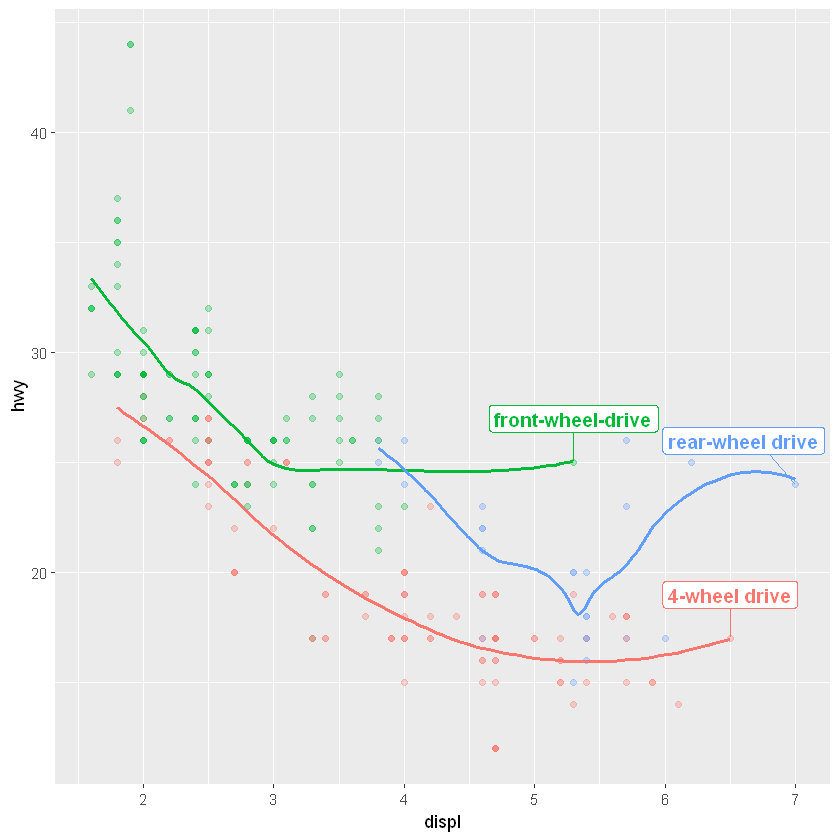

In [9]:
ggplot(mpg, aes(x = displ, y = hwy, color = drv)) +
  geom_point(alpha = 0.3) +
  geom_smooth(se = FALSE) +
  geom_label_repel(
    data = label_info, 
    aes(x = displ, y = hwy, label = drive_type),
    fontface = "bold", size = 4, nudge_y = 2
  ) +
  theme(legend.position = "none")

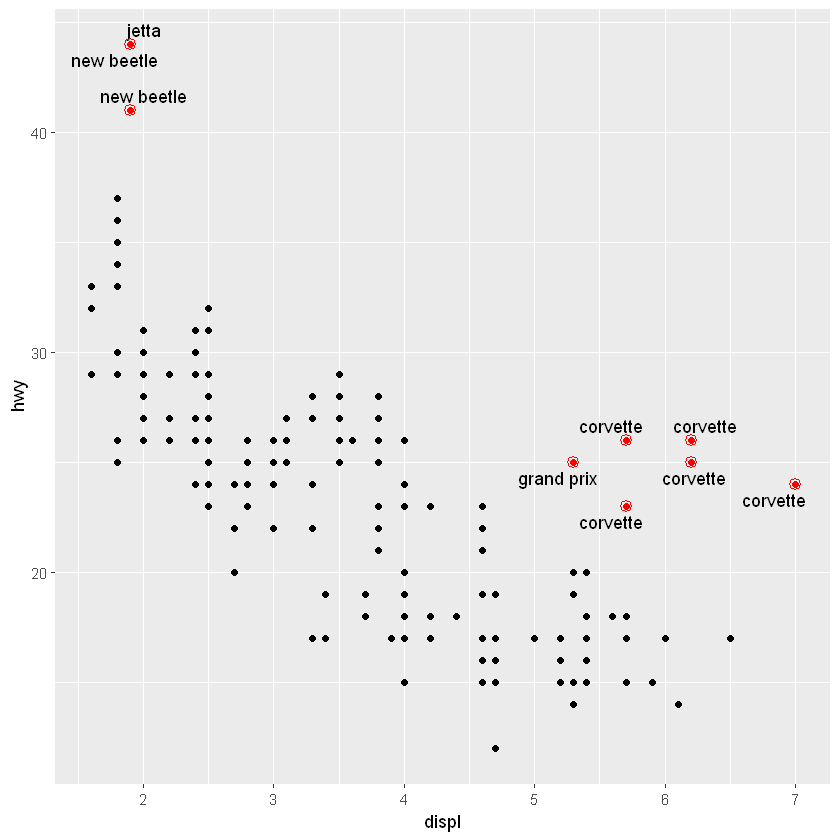

In [27]:
# ggrepel 패키지 - 플롯의 특정 지점 강조 geom_text_repel() 
potential_outliers <-mpg |>
filter(hwy >40 |(hwy>20 & displ >5))

ggplot(mpg,aes(x=displ,y=hwy))+
geom_point()+
geom_text_repel(data=potential_outliers, aes(label=model)) +
geom_point(data= potential_outliers, color="red")+
geom_point(data= potential_outliers, 
           color="red", size=3, shape="circle open")

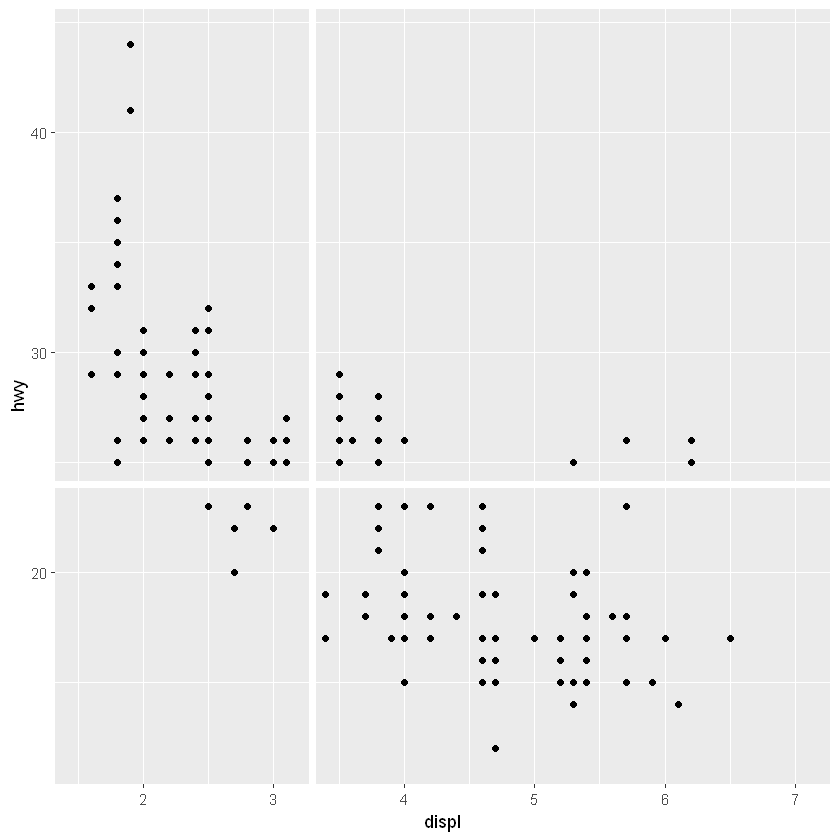

In [33]:
# geom_hline() 및 geom_vline: 기준선 추가
ggplot(mpg, aes(x = displ, y = hwy)) +
  geom_point() +
  geom_hline(yintercept = median(mpg$hwy), color = "white", linewidth = 2) +
  geom_vline(xintercept = median(mpg$displ), color = "white", linewidth = 2)

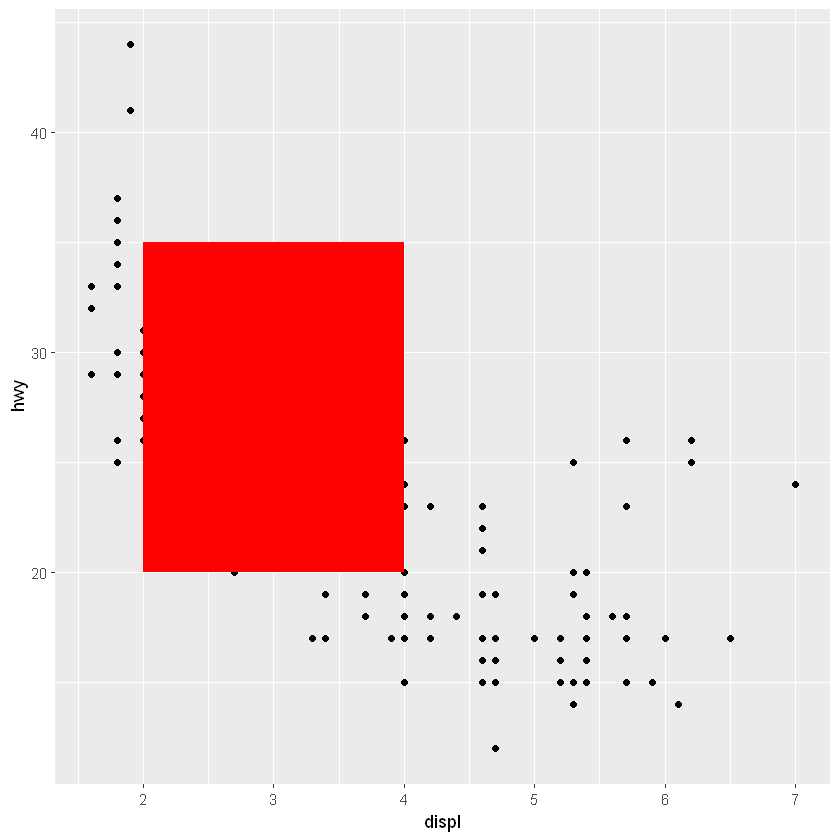

In [42]:
# geom_rect() : 관심 있는 데이터 영역을 직사각형을 둘러싸 강조
# 직사각형 경계는 xmin, xmax, ymin, ymax aesthetics로 정의
# ggforce 패키지의 geom_mark_hull()은 특정데이터 하위집합 주위는 볼록 다각형으로 감싸는 주석을 추가
ggplot(mpg, aes(x = displ, y = hwy)) +
  geom_point() +
  geom_rect(aes(xmin = 2, xmax = 4, ymin = 20, ymax = 35), fill = "red", alpha = 0.2)

In [43]:
trend_text <- "Larger engine sizes tend to have lower fuel economy." |>
  str_wrap(width = 30) #문자 수에 따라 자동으로 줄 바꿈
trend_text

[1] "Larger engine sizes tend to\nhave lower fuel economy."

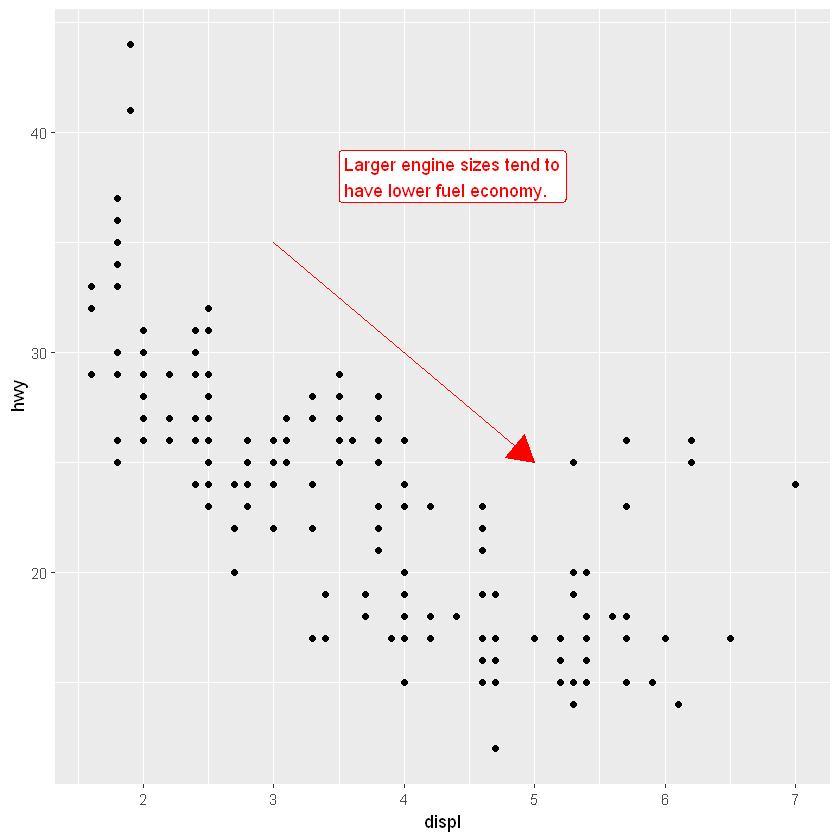

In [45]:
ggplot(mpg,aes(x=displ,y=hwy))+
geom_point()+
annotate(
geom = "label", x=3.5, y=38,
label=trend_text,
hjust="left",color="red")+
annotate(
geom="segment",
x=3,y=35,xend=5,yend=25,color="Red",
arrow=arrow(type="closed"))

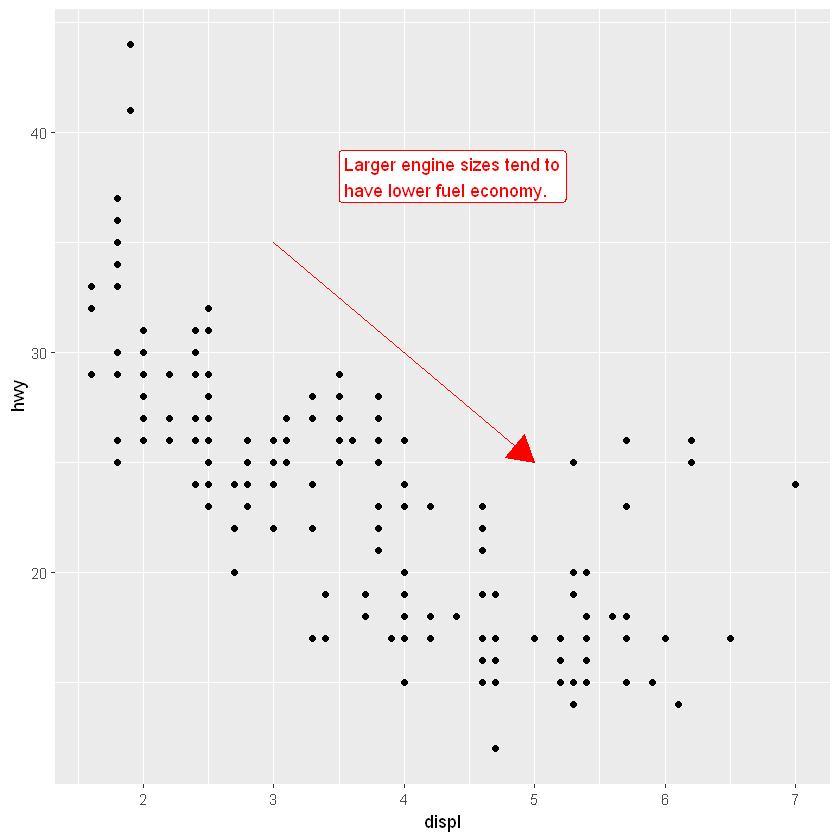

In [55]:
ggplot(mpg, aes(x = displ, y = hwy)) +
  geom_point() +
  annotate(
    geom = "label", x = 3.5, y = 38,
    label = trend_text,
    hjust = "left", color = "red"
  ) +
  annotate(
    geom = "segment",
    x = 3, y = 35, xend = 5, yend = 25, color = "red",
    arrow = arrow(type = "closed")
  )

In [56]:
install.packages('ggthemes', dependencies = TRUE)

Installing package into 'C:/Users/LG/AppData/Local/R/win-library/4.3'
(as 'lib' is unspecified)

also installing the dependencies 'extrafontdb', 'Rttf2pt1', 'cyclocomp', 'xmlparsedata', 'hunspell', 'extrafont', 'lintr', 'maps', 'mapproj', 'pander', 'spelling', 'vdiffr'




package 'extrafontdb' successfully unpacked and MD5 sums checked
package 'Rttf2pt1' successfully unpacked and MD5 sums checked
package 'cyclocomp' successfully unpacked and MD5 sums checked
package 'xmlparsedata' successfully unpacked and MD5 sums checked
package 'hunspell' successfully unpacked and MD5 sums checked
package 'extrafont' successfully unpacked and MD5 sums checked
package 'lintr' successfully unpacked and MD5 sums checked
package 'maps' successfully unpacked and MD5 sums checked
package 'mapproj' successfully unpacked and MD5 sums checked
package 'pander' successfully unpacked and MD5 sums checked
package 'spelling' successfully unpacked and MD5 sums checked
package 'vdiffr' successfully unpacked and MD5 sums checked
package 'ggthemes' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\LG\AppData\Local\Temp\RtmpyQ8fT2\downloaded_packages


In [57]:
library("ggthemes")

mtcars2 <- within(mtcars, {
  vs <- factor(vs, labels = c("V-shaped", "Straight"))
  am <- factor(am, labels = c("Automatic", "Manual"))
  cyl  <- factor(cyl)
  gear <- factor(gear)
})

p1 <- ggplot(mtcars2) +
  geom_point(aes(x = wt, y = mpg, colour = gear)) +
  labs(
    title = "Fuel economy declines as weight increases",
    subtitle = "(1973-74)",
    caption = "Data from the 1974 Motor Trend US magazine.",
    x = "Weight (1000 lbs)",
    y = "Fuel economy (mpg)",
    colour = "Gears"
  )

Warning message:
"package 'ggthemes' was built under R version 4.3.3"


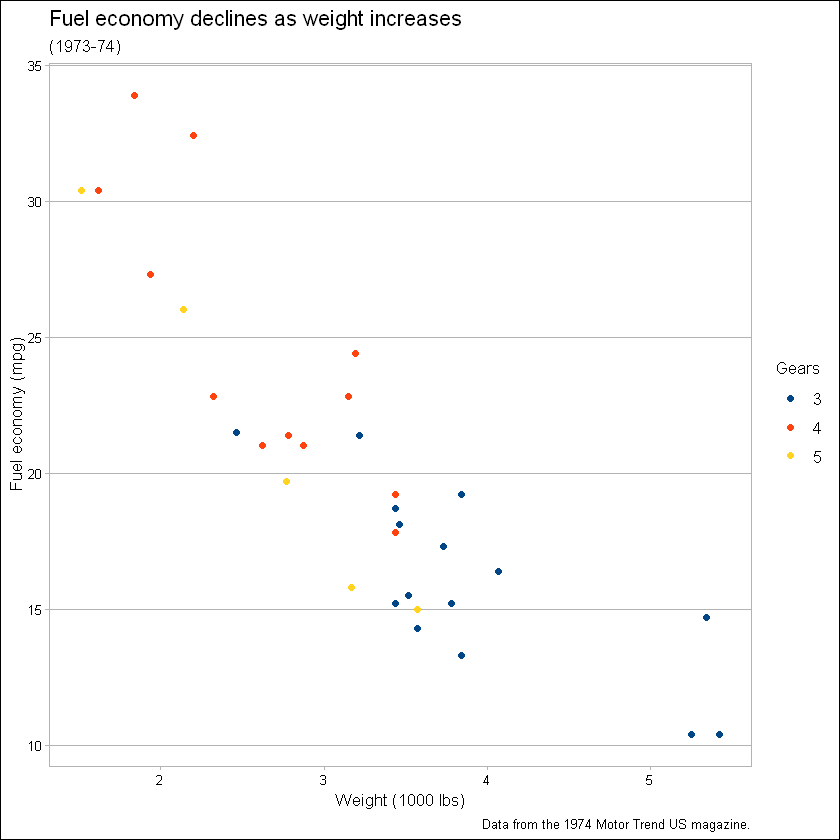

In [58]:
p1 +
  scale_color_calc() +
  theme_calc()

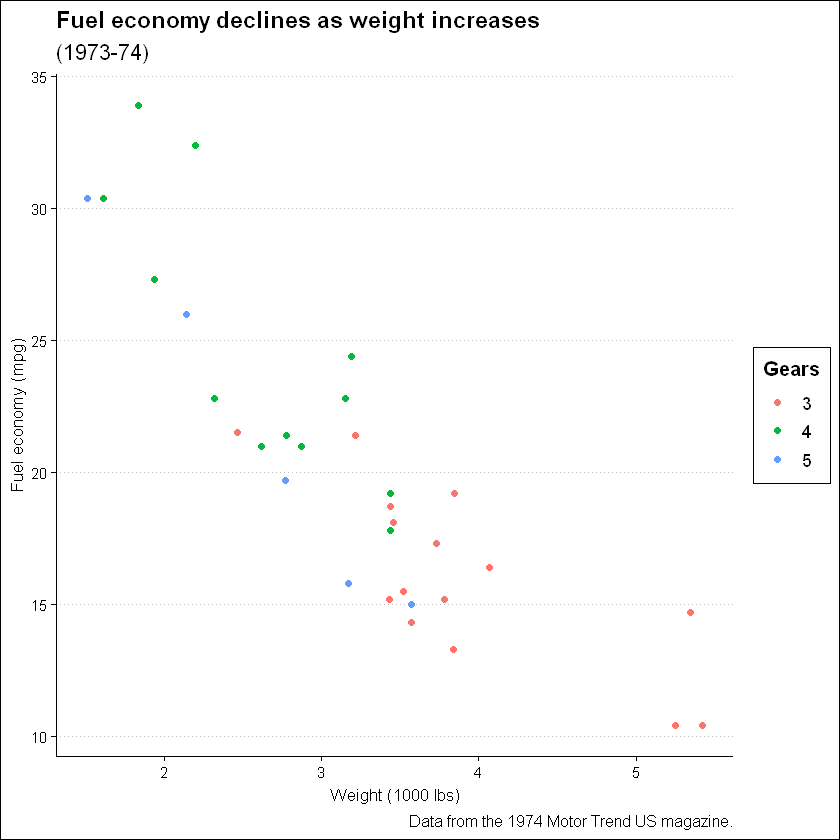

In [59]:
p1 + theme_clean()

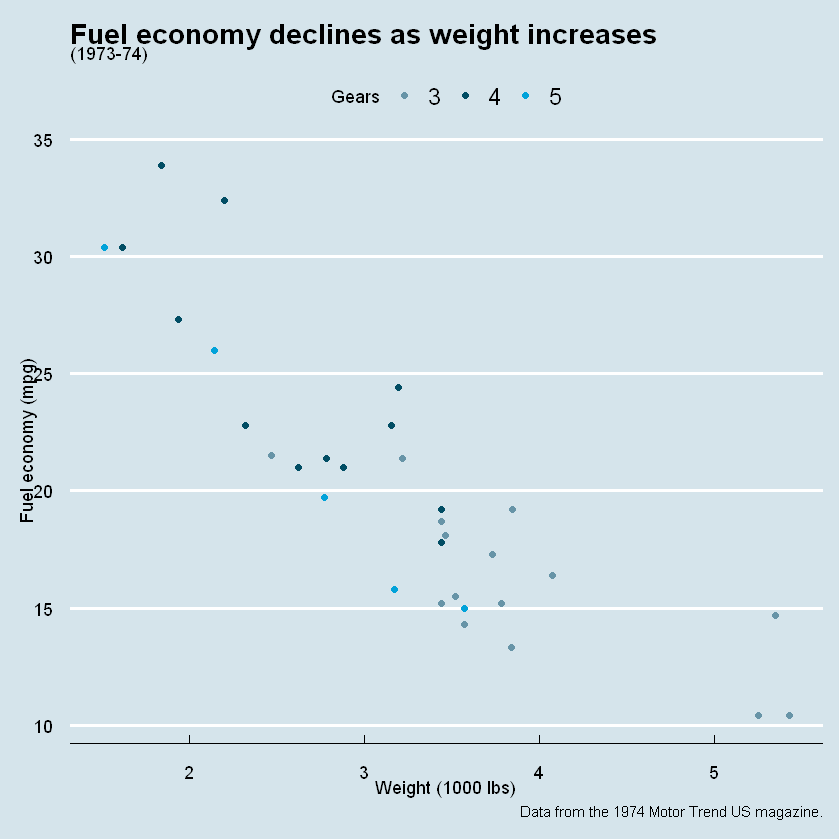

In [60]:
p1 + theme_economist() +
  scale_colour_economist()

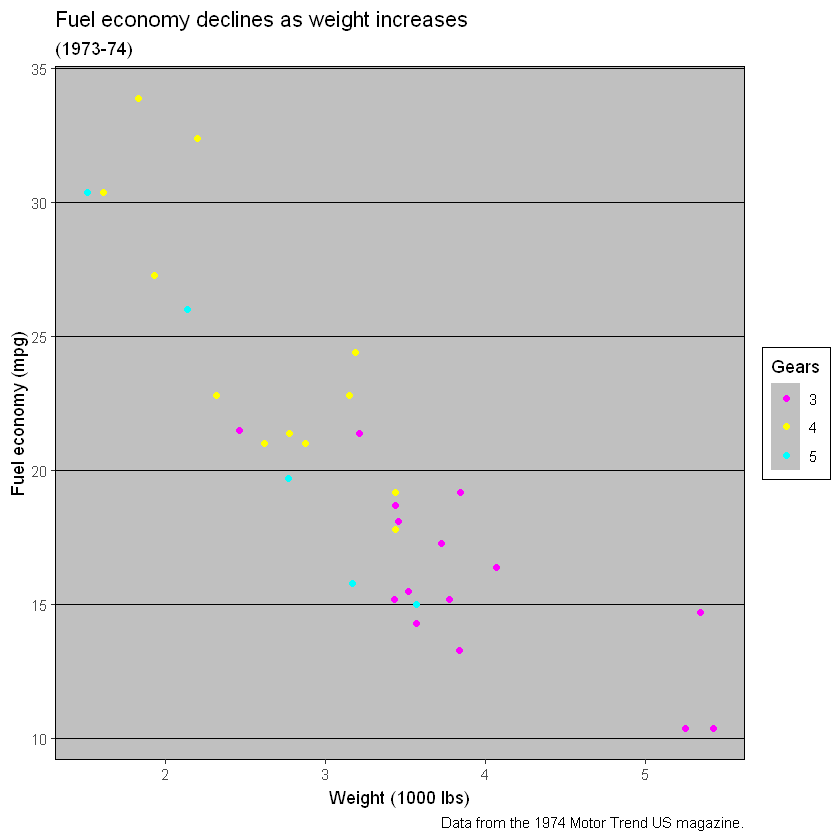

In [61]:
p1 + theme_excel() +
  scale_colour_excel()

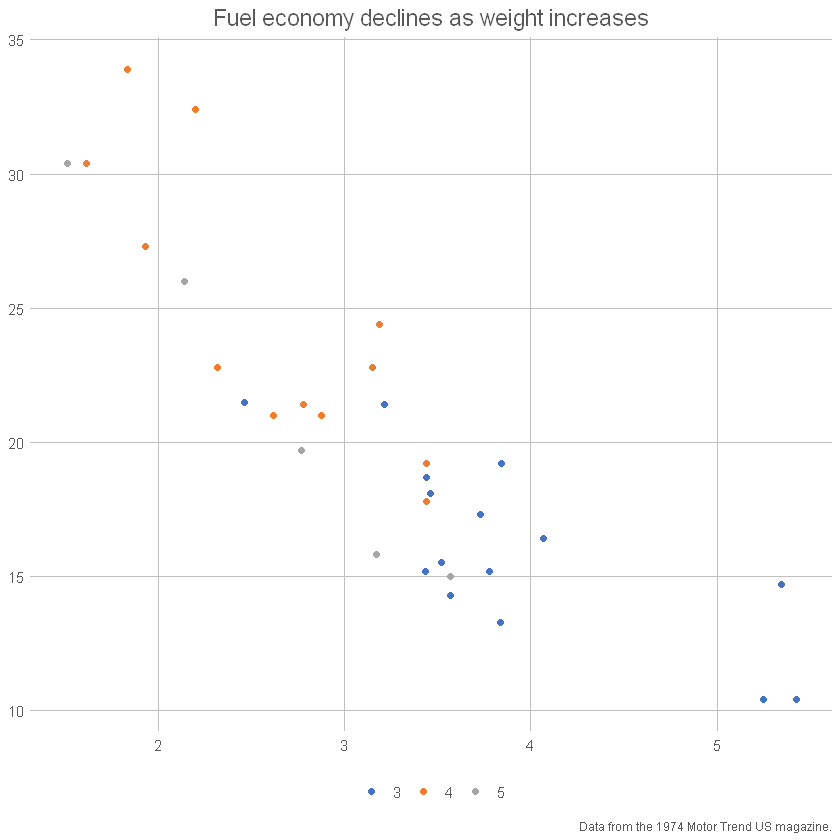

In [62]:
p1 + theme_excel_new() +
  scale_colour_excel_new()

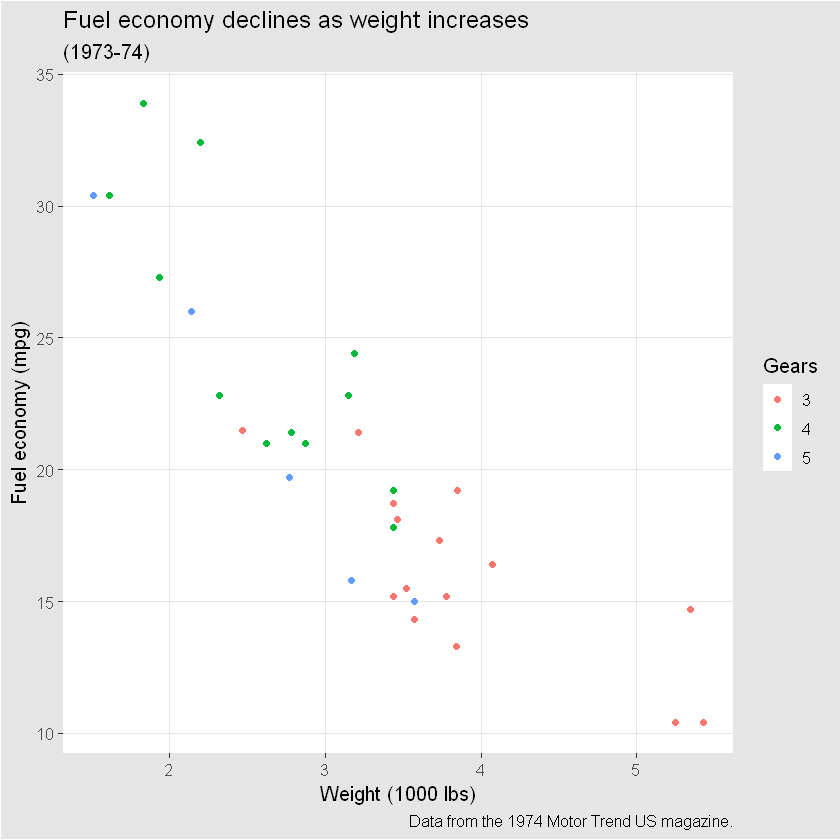

In [63]:
p1 + theme_igray()

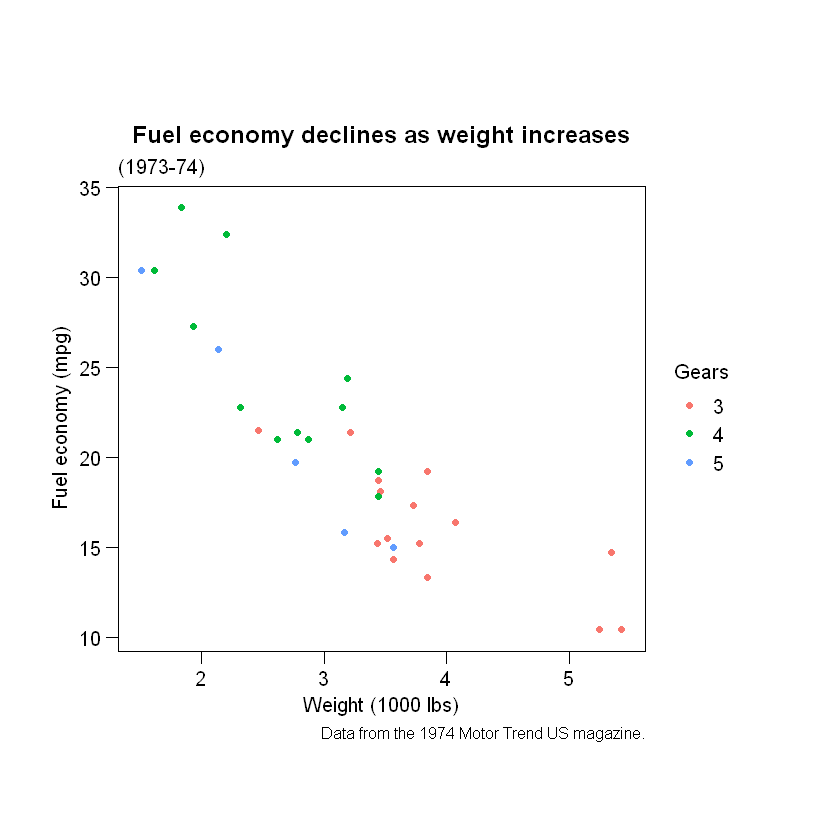

In [64]:
p1 + theme_par()

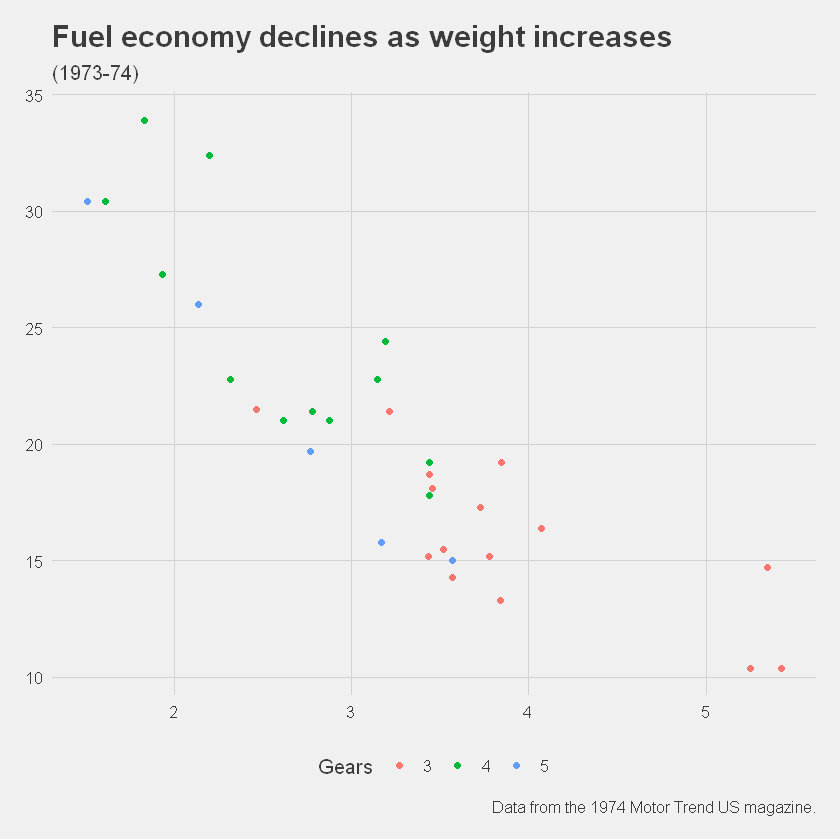

In [65]:
p1 + theme_fivethirtyeight()

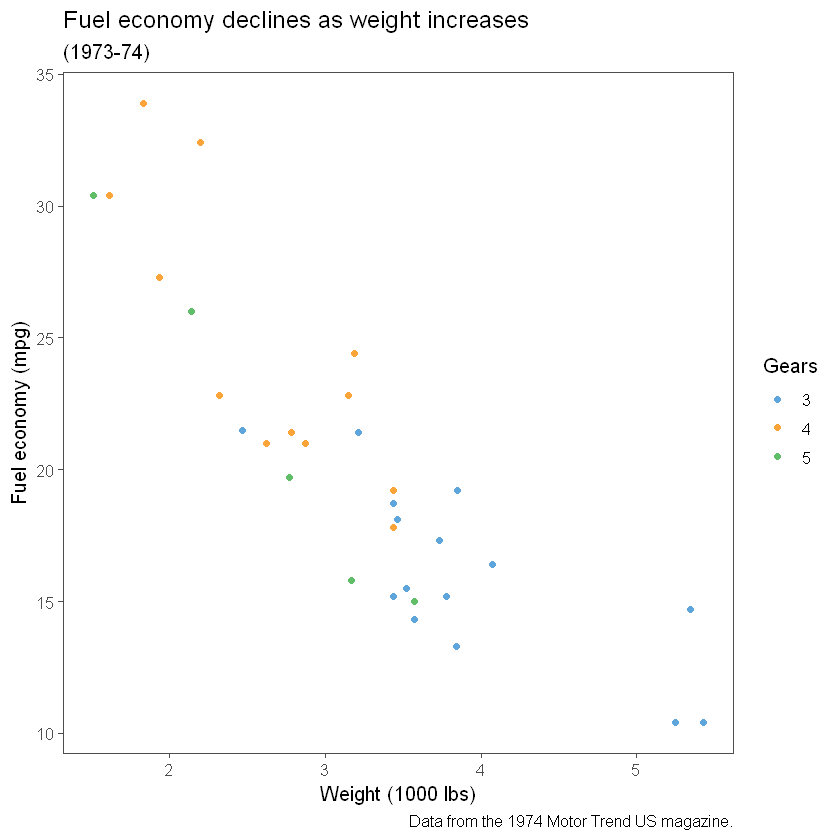

In [66]:
p1 + theme_few() +
  scale_colour_few()

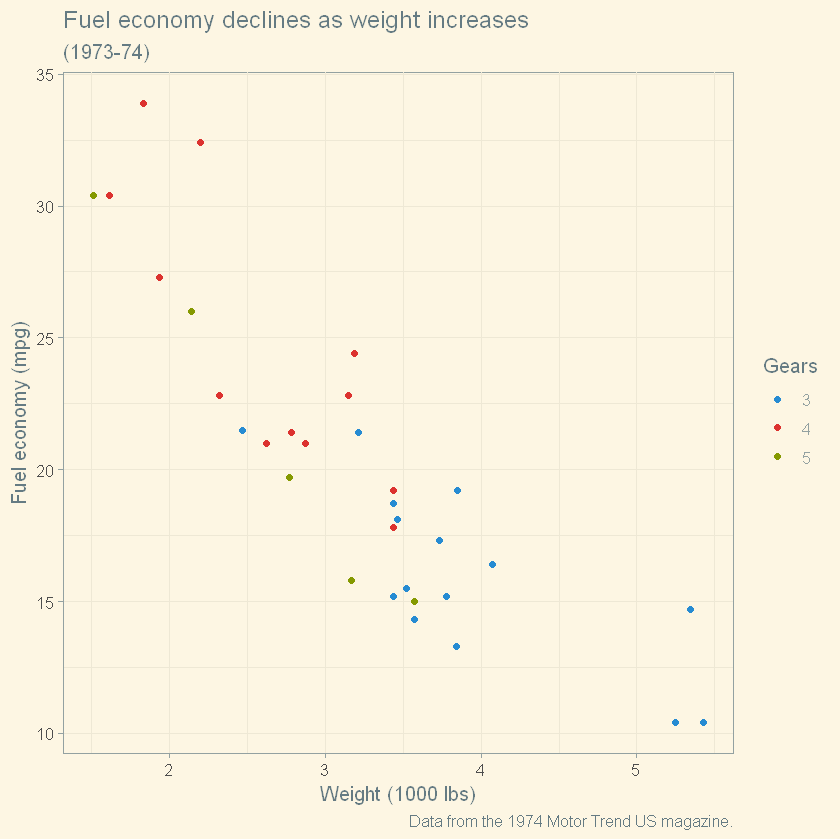

In [67]:
p1 + theme_solarized() +
  scale_colour_solarized()

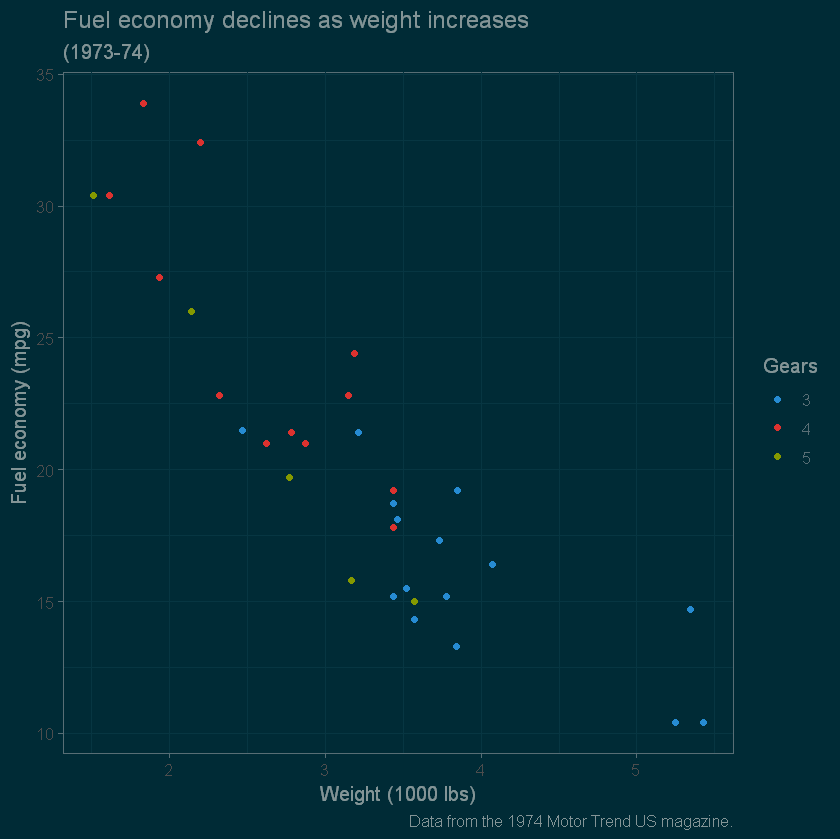

In [68]:
p1 + theme_solarized(light=FALSE) +
  scale_colour_solarized()

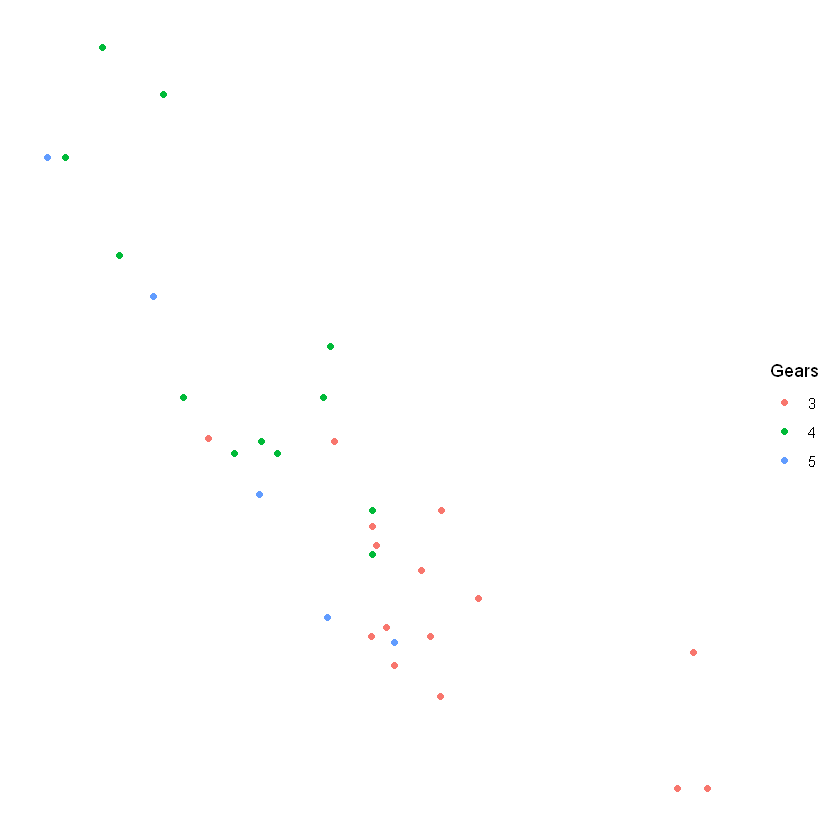

In [70]:
p1 + theme_solid()

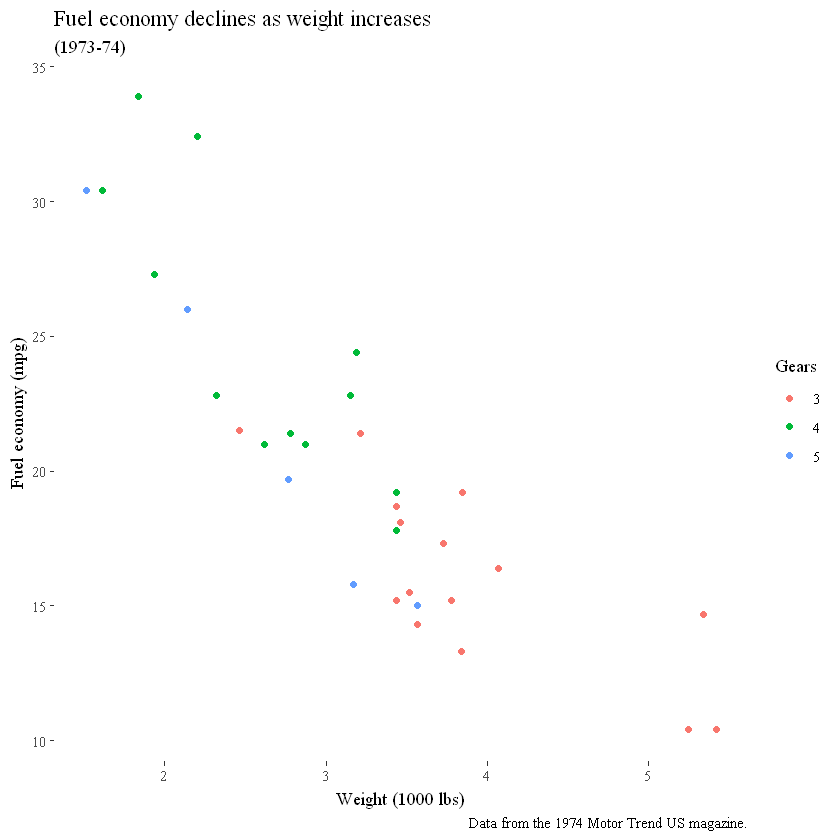

In [71]:
p1 + theme_tufte()

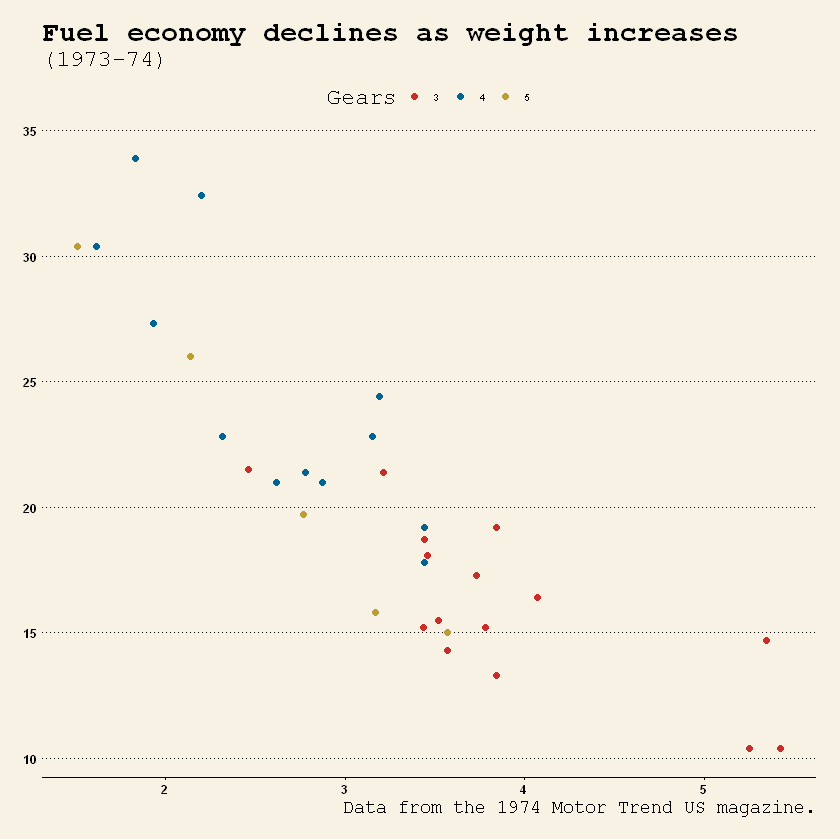

In [74]:
p1 + theme_wsj(base_size = 7) + scale_color_wsj()

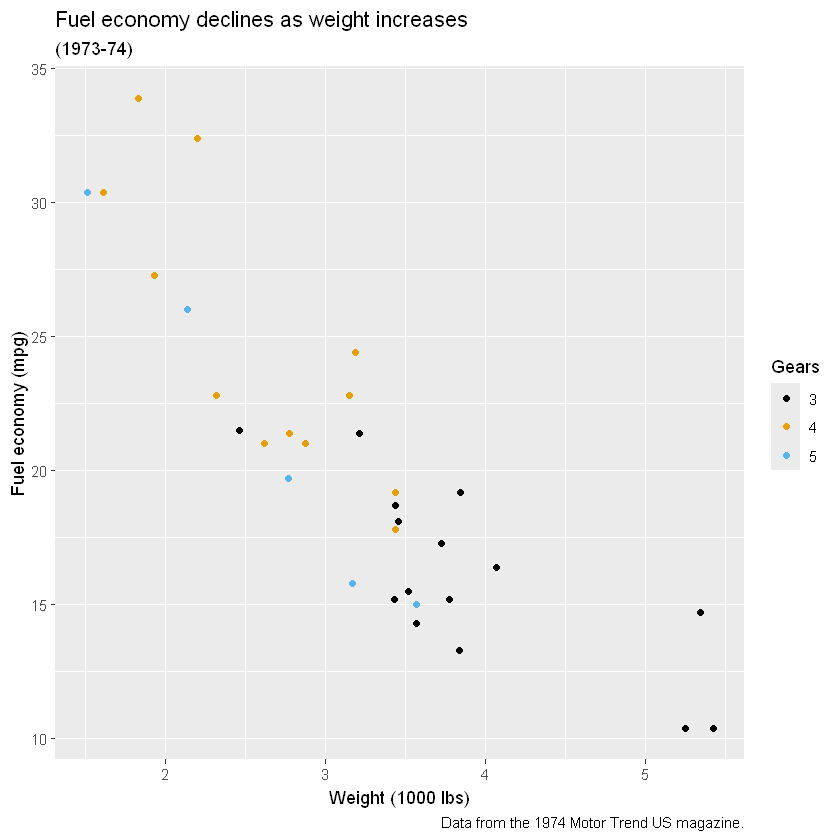

In [75]:
p1 + scale_color_colorblind()

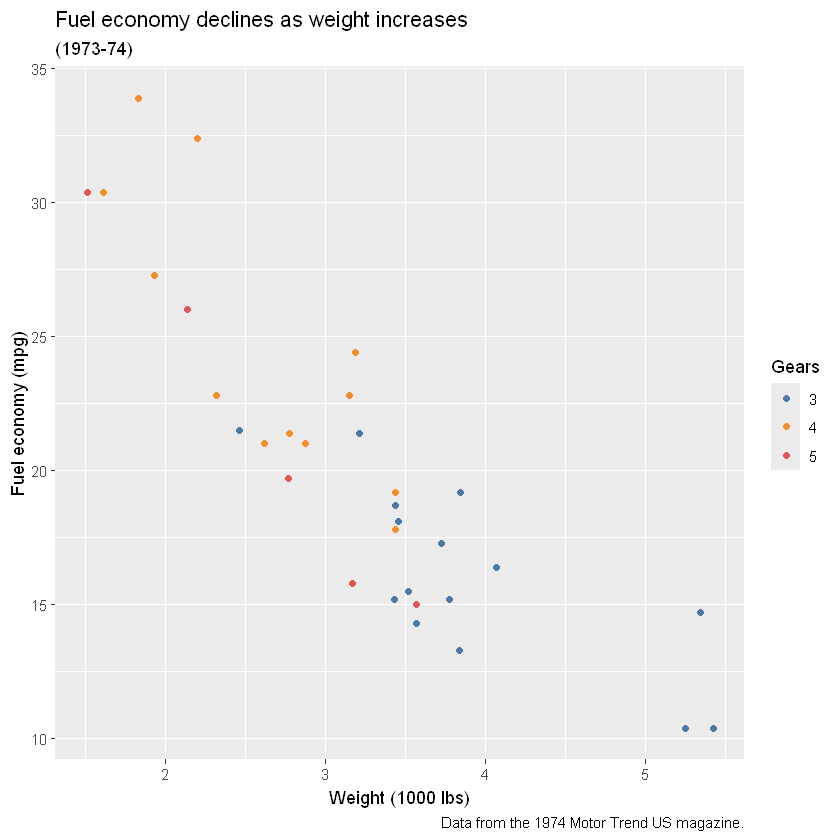

In [76]:
p1 + scale_color_tableau()